In [70]:
# for the following data plot each of them next to each other for N: [1, 10, 100, 1000, 10000, 100000]
# aot local 		=	N X 604772
# jit local		=	N X 512212
# jit remote		=	(N X 348044) + 359372
# truejit remote	=	(N X 348376) + 400400


In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import bokeh.palettes

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

[0 1 2 3]


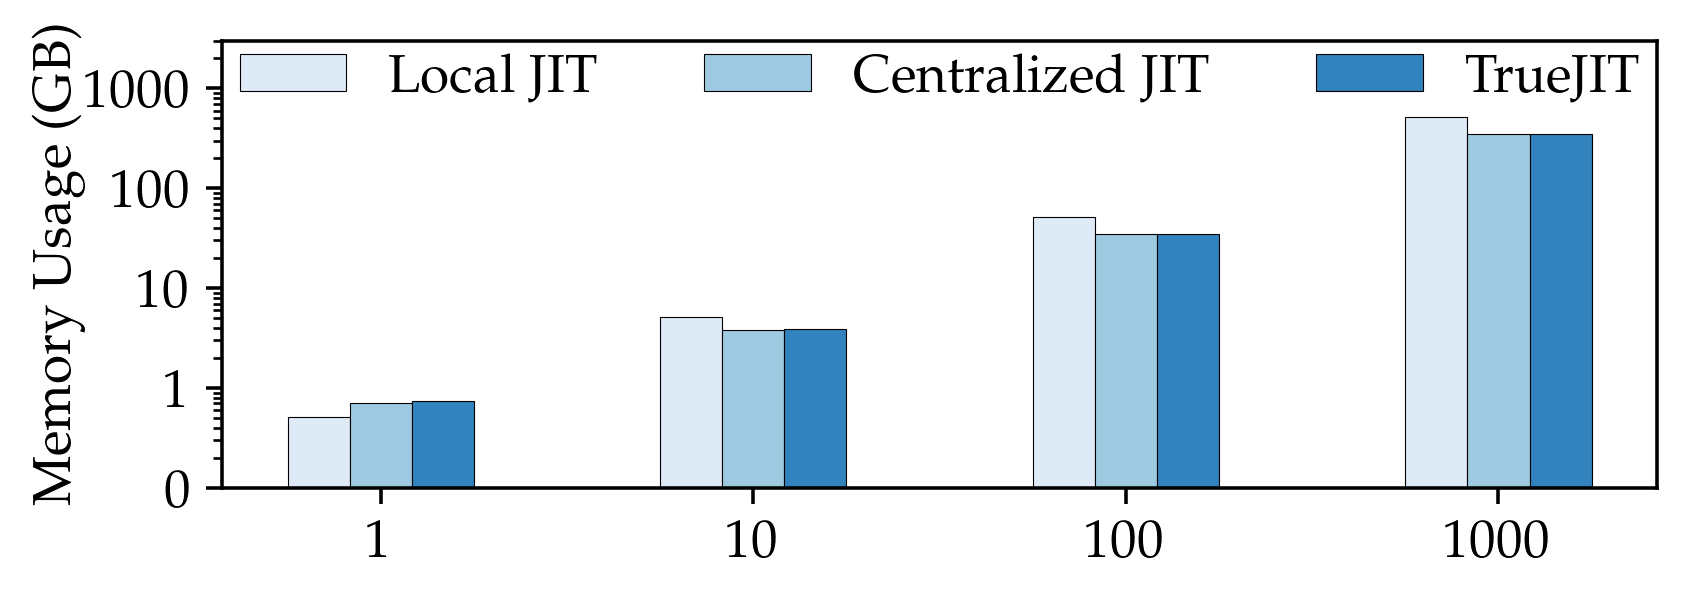

In [72]:
import numpy as np

local_jit_memory_calculator = lambda n: n * 512212
centralized_jit_memory_calculator = lambda n: (n * 348044) + 359372
true_jit_memory_calculator = lambda n: (n * 348376) + 400400

colors = bokeh.palettes.Blues3
colors = colors[::-1]

nodes = [1, 10, 100, 1000]

# line plot for each memory usage
fig, ax = plt.subplots(figsize=(5.5, 2), dpi=320)

# bar chart next to each other
bar_width = .5 / 3

xs = np.arange(len(nodes))
print(xs)

for i, memory_calculator in enumerate([local_jit_memory_calculator, centralized_jit_memory_calculator,
                                       true_jit_memory_calculator]):
    memory = [memory_calculator(n) for n in nodes]
    ax.bar(xs + i * bar_width - bar_width, memory, bar_width, color=colors[i], edgecolor='black', linewidth=0.25)

# for opt, node in enumerate(nodes):
    # show memory saving of true jit over local jit on top of bar
    # memory_saving = local_jit_memory_calculator(node) - true_jit_memory_calculator(node)
    # ax.text(opt, 1.6 * centralized_jit_memory_calculator(node), f'{memory_saving / 1024 ** 2:.1f} GB', ha='center',
    #         fontsize=12)

ax.set_xticks(xs)
ax.set_xticklabels(nodes, fontsize=12)

# y is log
plt.yscale('log')
# y limit
plt.ylim(1e5, 3e9)
# y ticks [0, 1GB, 10GB, 100GB, 1000GB]
plt.yticks([1e5, 1e6, 1e7, 1e8, 1e9], ['0', '1', '10', '100', '1000'], fontsize=12)
# y label
plt.ylabel('Memory Usage (GB)', labelpad=0, fontsize=12)

# legend is ["Local JIT", "Centralized JIT", "TrueJIT"]
plt.legend(["Local JIT", "Centralized JIT", "TrueJIT"], loc='upper center', ncol=3, frameon=False, fontsize=12,
           bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()

# to pdf
plt.savefig('out/cluster_memory_usage.pdf', format='pdf', bbox_inches='tight', dpi=320, pad_inches=0.1)

plt.show()